<a href="https://colab.research.google.com/github/mmouree/Machine-Learning/blob/Assignments/ML_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons, make_swiss_roll
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [ ]:
def run_kmeans_gmm(X, n_clusters):
    # K-Means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X)
    kmeans_score = silhouette_score(X, kmeans_labels)

    # GMM
    gmm = GaussianMixture(n_components=n_clusters, random_state=42)
    gmm_labels = gmm.fit_predict(X)
    gmm_score = silhouette_score(X, gmm_labels)

    return kmeans_score, gmm_score

In [ ]:
# Vary true centers in make_blobs

results = []

true_centers_list = [2, 3, 4, 5, 6]

for true_centers in true_centers_list:
    X, y_true = make_blobs(
        n_samples=1000,
        n_features=2,
        centers=true_centers,
        cluster_std=1.0,
        random_state=42
    )

    # Set predicted clusters/components less than true centers
    predicted_clusters = max(2, true_centers - 1)

    kmeans_score, gmm_score = run_kmeans_gmm(X, predicted_clusters)

    results.append({
        "true_centers": true_centers,
        "predicted_clusters/components": predicted_clusters,
        "KMeans_silhouette": kmeans_score,
        "GMM_silhouette": gmm_score
    })

blob_results = pd.DataFrame(results)
blob_results

,true_centers,predicted_clusters/components,KMeans_silhouette,GMM_silhouette
0,2,2,0.825246,0.825246
1,3,2,0.705284,0.705284
2,4,3,0.752196,0.752196
3,5,4,0.727041,0.724816
4,6,5,0.659691,0.659633


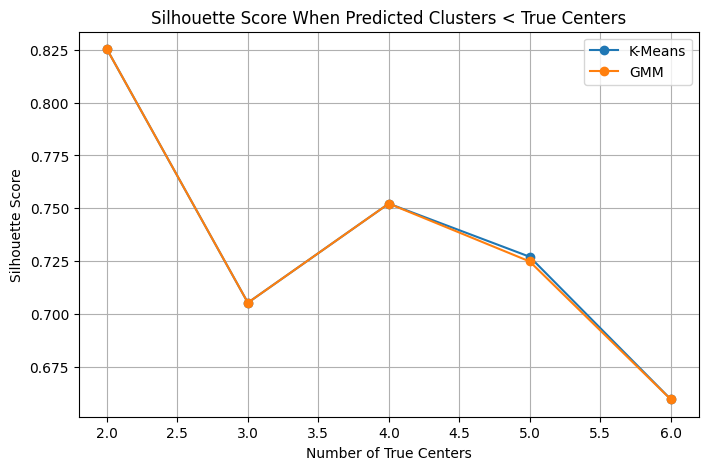

In [ ]:
# Plot blob results

plt.figure(figsize=(8, 5))
plt.plot(blob_results["true_centers"], blob_results["KMeans_silhouette"], marker="o", label="K-Means")
plt.plot(blob_results["true_centers"], blob_results["GMM_silhouette"], marker="o", label="GMM")
plt.xlabel("Number of True Centers")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score When Predicted Clusters < True Centers")
plt.legend()
plt.grid(True)
plt.show()

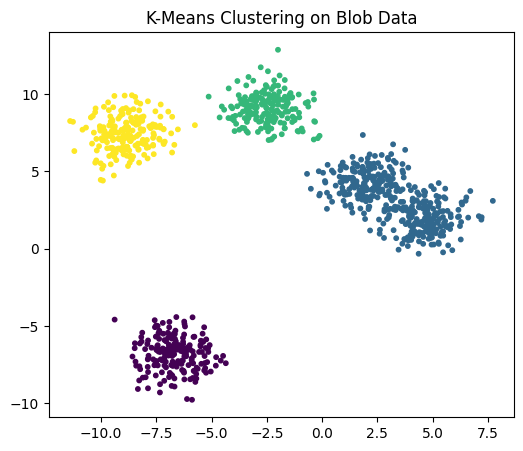

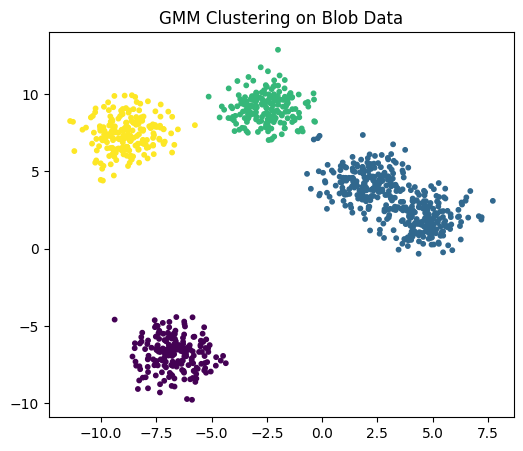

In [ ]:
# Visualize one blob example

X, y_true = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=5,
    cluster_std=1.0,
    random_state=42
)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, s=10)
plt.title("K-Means Clustering on Blob Data")
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=gmm_labels, s=10)
plt.title("GMM Clustering on Blob Data")
plt.show()

In [ ]:
# Non-spherical dataset using make_moons

X_moons, y_moons = make_moons(
    n_samples=1000,
    noise=0.08,
    random_state=42
)

kmeans_score_moons, gmm_score_moons = run_kmeans_gmm(X_moons, n_clusters=2)

print("Moons Dataset")
print("K-Means Silhouette Score:", kmeans_score_moons)
print("GMM Silhouette Score:", gmm_score_moons)

Moons Dataset
K-Means Silhouette Score: 0.48516993202846087
GMM Silhouette Score: 0.46626542544901295


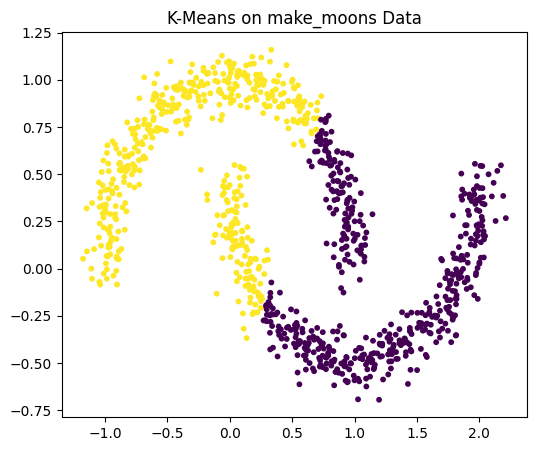

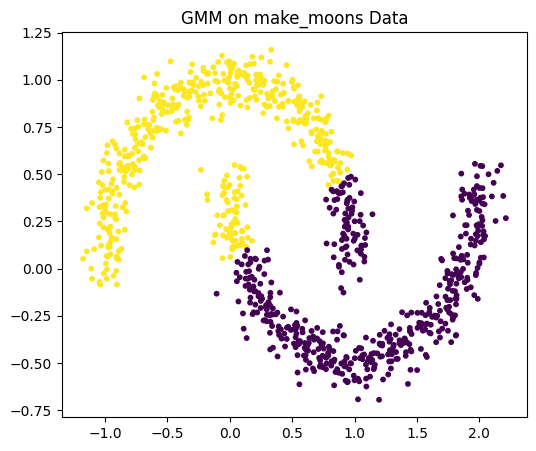

In [ ]:
# Visualize make_moons clustering

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_moons)

gmm = GaussianMixture(n_components=2, random_state=42)
gmm_labels = gmm.fit_predict(X_moons)

plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=kmeans_labels, s=10)
plt.title("K-Means on make_moons Data")
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=gmm_labels, s=10)
plt.title("GMM on make_moons Data")
plt.show()

In [ ]:
# Swiss Roll dataset

X_swiss, color = make_swiss_roll(
    n_samples=1000,
    noise=0.1,
    random_state=42
)

X_swiss_2d = X_swiss[:, [0, 2]]

kmeans_score_swiss, gmm_score_swiss = run_kmeans_gmm(X_swiss_2d, n_clusters=3)

print("Swiss Roll Dataset")
print("K-Means Silhouette Score:", kmeans_score_swiss)
print("GMM Silhouette Score:", gmm_score_swiss)

Swiss Roll Dataset
K-Means Silhouette Score: 0.4426316540454835
GMM Silhouette Score: 0.37647193689047287


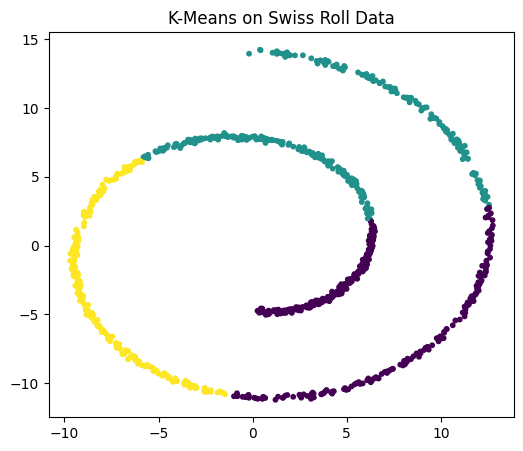

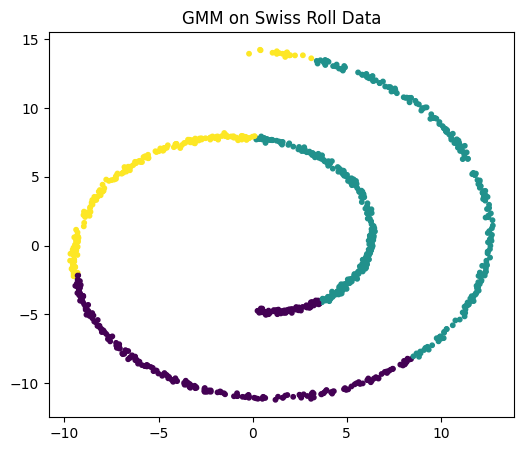

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_swiss_2d)

gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_swiss_2d)

plt.figure(figsize=(6, 5))
plt.scatter(X_swiss_2d[:, 0], X_swiss_2d[:, 1], c=kmeans_labels, s=10)
plt.title("K-Means on Swiss Roll Data")
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(X_swiss_2d[:, 0], X_swiss_2d[:, 1], c=gmm_labels, s=10)
plt.title("GMM on Swiss Roll Data")
plt.show()

When the number of predicted clusters/components is less than the number of true centers, the silhouette score usually decreases because different true clusters are forced to merge together. For globular blob-shaped clusters, K-Means and GMM usually produce similar results because both methods work well when clusters are compact and roughly spherical.

For non-spherical datasets such as make_moons or swiss roll, both K-Means and GMM perform worse because the cluster shapes are not circular or Gaussian-like. K-Means tends to split the data based on distance to centroids, while GMM models the data using Gaussian components. GMM may sometimes perform slightly better because it can model elliptical clusters, but it still struggles with curved shapes like moons or swiss roll. Therefore, K-Means and GMM are more suitable for globular clusters than irregularly shaped clusters.